# Two Types - Congruent

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from tfds.plotting import prettify, use_tex

#use_tex()

In [5]:
def D(prob_state0):
    return 1 - 3 * prob_state0 + 2 * (prob_state0**2)

def gamma_critical_l(theta_h, theta_l, tau, prob_state0):
    return (1 - theta_l - tau * D(prob_state0)) / (1 - theta_h - tau * D(prob_state0))

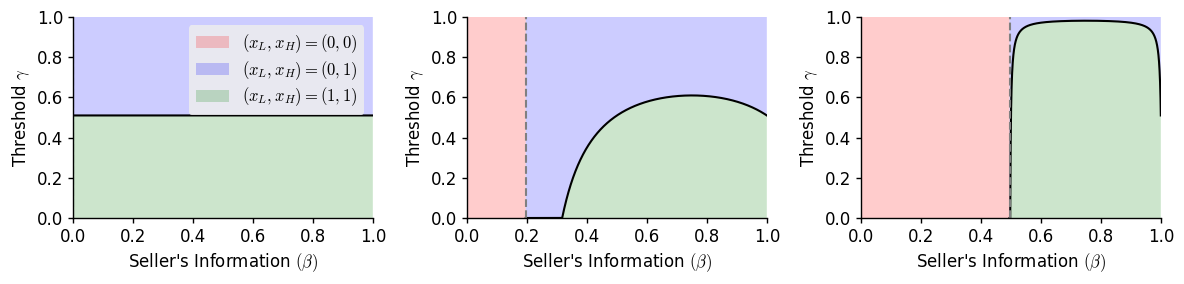

In [14]:
theta_h = 0.51
theta_l = 0.75
tau = 1
N = 10000

prob_state0s = np.linspace(0, 1, N)



fig, axs  = plt.subplots(1, 3, figsize=(12, 3 ))
taus = [0, 1, 100]

for i, tau in enumerate(taus):
    ax = axs[i]


    gamma_critical_ls = gamma_critical_l(theta_h, theta_l, tau, prob_state0s)
    with np.errstate(divide='ignore'):
        tau_critical = (1 - theta_h) / D(prob_state0s)
    tau_critical[tau_critical < 0] = np.nan
    mask = tau >= tau_critical
    gamma_critical_ls[mask] = np.nan
    gamma_critical_ls[gamma_critical_ls <= 0] = 0


    ax.plot(prob_state0s, gamma_critical_ls, ls="solid", color="k")
    ax.set_ylim(top=1, bottom=0)
    ax.set_xlim(left=0, right=1)

    ax.fill_between(
        prob_state0s[np.isnan(gamma_critical_ls)], 
        2,
        facecolor="red", 
        alpha=.2,
        label=r"$(x_L, x_H) = (0, 0)$"
        )

    ax.fill_between(
        prob_state0s, 
        gamma_critical_ls,
        2, 
        facecolor="blue", 
        alpha=.2,
        label=r"$(x_L, x_H) = (0, 1)$"
    )

    ax.fill_between(
        prob_state0s, 
        0,
        gamma_critical_ls, 
        facecolor="green", 
        alpha=.2,
        label=r"$(x_L, x_H) = (1, 1)$"
    )

    ax.vlines(
        x=prob_state0s[np.isnan(gamma_critical_ls).sum()],
        ymin=0,
        ymax=2,
        ls="dashed", 
        color="gray"
        )   

    # if i == 0:
    #     ax.legend(ncol=1)

    prettify(ax=ax, legend=True if i == 0 else False)

    ax.set_xlabel(r"Seller's Information $(\beta)$")
    ax.set_ylabel(r"Threshold $\gamma$")


In [39]:
from scipy.optimize import minimize 

def objective(vars):
    x_l, x_h, trans_h, trans_l = vars
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

def constraint1(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * (x_h - x_l) - (trans_h - trans_l)


def constraint2(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * (x_l - x_h) - (trans_l - trans_h)


def constraint3(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * x_l - trans_l

def constraint4(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * x_h - trans_h

bounds = [(0, 1), (0, 1), (0, None), (0, None)]

# Initial guess for the variables
tau = 0
prob_state0 = 0.5
theta_h = 0.51
theta_l = 0.55
gamma = 0.3


constraints = [
        {'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4},
    ]
x0 = [1, 1, 1, 1]
result = minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )

    
result.x

array([1.  , 1.  , 0.45, 0.45])

In [36]:
# in this case the ir_high does not always bind

In [37]:
x_l, x_h, trans_h, trans_l  = result.x

In [38]:
(1 - theta_h) * x_h - trans_h

np.float64(-1.6653345369377348e-16)

In [48]:
from scipy.optimize import minimize 

def objective(vars):
    x_l, x_h, trans_h, trans_l = vars
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

def constraint1(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * (x_h - x_l) - (trans_h - trans_l)


def constraint2(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * (x_l - x_h) - (trans_l - trans_h)


def constraint3(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * x_l - trans_l

def constraint4(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * x_h - trans_h

    
bounds = [(1, 1), (1, 1), (0, None), (0, None)]

# Initial guess for the variables
tau = 0.4
prob_state0 = 0.5
theta_h = 0.5
theta_l = 0.7
gamma = 0.3


constraints = [
        {'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4},
    ]
x0 = [1, 1, 1, 1]
result = minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )

    
result.fun

-0.1000000000000004